<a href="https://colab.research.google.com/github/avantikabijalwan19-ux/Data_science_assignment/blob/main/DS_EDA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<b> The International Cricket Council (ICC) is the world governing body of cricket. It was founded as the Imperial Cricket Conference in 1909 by representatives from Australia, England and South Africa. It was renamed as the International Cricket Conference in 1965, and took up its current name in 1989. It organises world championship events such as Cricket World Cup, Women's Cricket World Cup, ICC T20 World Cup, ICC Women's T20 World Cup, ICC Champions Trophy and Under-19 Cricket World Cup.</b>

<br>

## <b> You recently got a lucky break in the field of Data Science. You got a job of Data Scientist at ICC. You are part of the Analytics Team which is involved in pre-match analyses, live-match analyses and post-match analyses. </b>

<br>

## <b>This data consists of 1417 T20 matches. Each row corresponds to a single T20 match. As a data scientist, you have to first explore the data and check its sanity. </b>

<br>

## <u><b>Further you are required to do some analyses :</b></u>
* ### Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date
* ### Find out the top three venues which hosted the greatest number of matches.
* ### Find out the pair of cricket teams who played the most number of T20 matches against each other.
* ### Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.
* ### Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.




# <b><center> A sample scorecard </center></b>

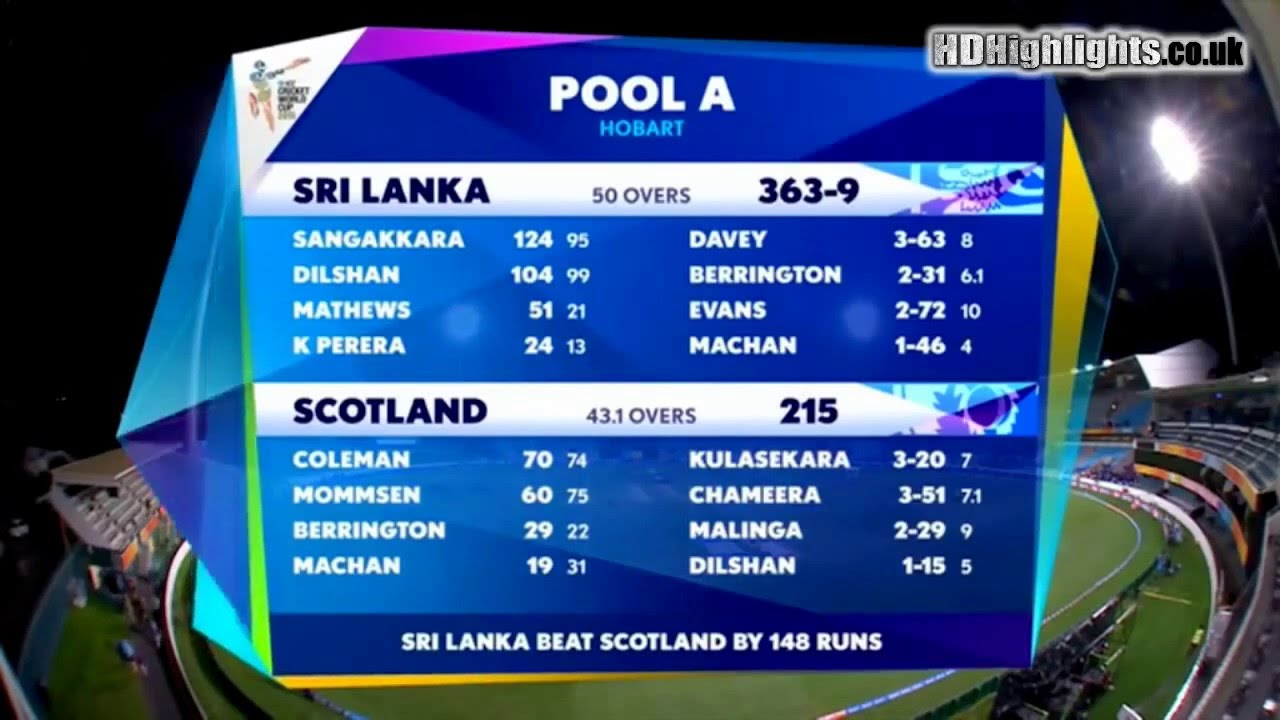

In [14]:

import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv('/content/International_T20_Data.csv', engine='python', on_bad_lines='skip')

In [16]:
df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.columns = df.columns.str.replace('.', '_')
print(df.columns)

Index(['innings', 'meta_data_version', 'meta_created', 'meta_revision',
       'info_dates', 'info_gender', 'info_match_type',
       'info_outcome_by_wickets', 'info_outcome_winner', 'info_overs',
       'info_player_of_match', 'info_teams', 'info_toss_decision',
       'info_toss_winner', 'info_umpires', 'info_venue', 'info_city',
       'info_outcome_by_runs', 'info_match_type_number', 'info_neutral_venue',
       'info_outcome_method', 'info_outcome_result', 'info_outcome_eliminator',
       'info_supersubs_New Zealand', 'info_supersubs_South Africa',
       'info_bowl_out', 'info_outcome_bowl_out'],
      dtype='object')


In [18]:
df.columns = df.columns.str.replace('.', '_', regex=False)
print("Updated Column Names:")
print(df.columns.tolist())

Updated Column Names:
['innings', 'meta_data_version', 'meta_created', 'meta_revision', 'info_dates', 'info_gender', 'info_match_type', 'info_outcome_by_wickets', 'info_outcome_winner', 'info_overs', 'info_player_of_match', 'info_teams', 'info_toss_decision', 'info_toss_winner', 'info_umpires', 'info_venue', 'info_city', 'info_outcome_by_runs', 'info_match_type_number', 'info_neutral_venue', 'info_outcome_method', 'info_outcome_result', 'info_outcome_eliminator', 'info_supersubs_New Zealand', 'info_supersubs_South Africa', 'info_bowl_out', 'info_outcome_bowl_out']


In [19]:
top_venues = df['info_venue'].value_counts().head(3)
print("Top 3 Venues by Number of Matches:")
print(top_venues)

Top 3 Venues by Number of Matches:
info_venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
R Premadasa Stadium                    34
Name: count, dtype: int64


In [20]:
df.columns = df.columns.str.replace('.', '_', regex=False)
print("Updated Column Names:")
print(df.columns.tolist())

Updated Column Names:
['innings', 'meta_data_version', 'meta_created', 'meta_revision', 'info_dates', 'info_gender', 'info_match_type', 'info_outcome_by_wickets', 'info_outcome_winner', 'info_overs', 'info_player_of_match', 'info_teams', 'info_toss_decision', 'info_toss_winner', 'info_umpires', 'info_venue', 'info_city', 'info_outcome_by_runs', 'info_match_type_number', 'info_neutral_venue', 'info_outcome_method', 'info_outcome_result', 'info_outcome_eliminator', 'info_supersubs_New Zealand', 'info_supersubs_South Africa', 'info_bowl_out', 'info_outcome_bowl_out']


Top 3 Venues by Number of Matches:
info_venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
R Premadasa Stadium                    34
Name: count, dtype: int64


/tmp/ipykernel_366/3968518148.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.index, y=top_venues.values, palette='viridis')


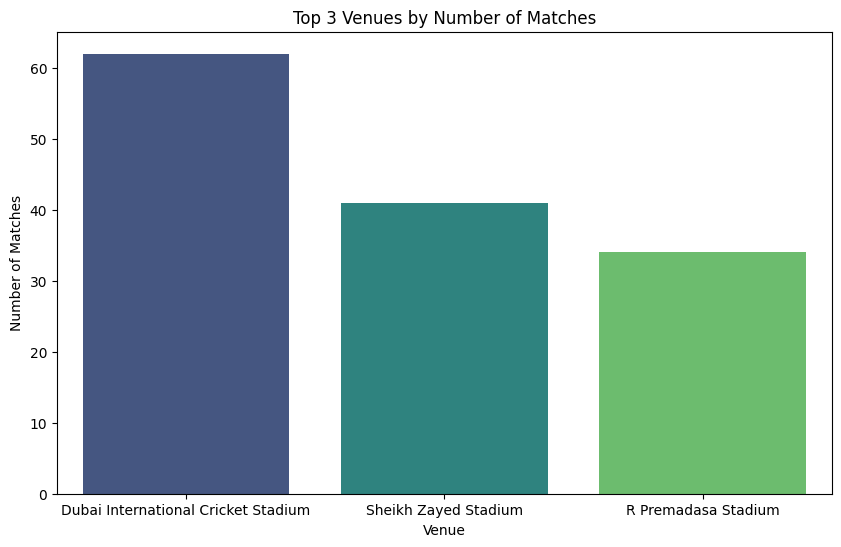

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/International_T20_Data.csv', engine='python', on_bad_lines='skip')
df.columns = df.columns.str.replace('.', '_', regex=False)

top_venues = df['info_venue'].value_counts().head(3)
print("Top 3 Venues by Number of Matches:")
print(top_venues)


plt.figure(figsize=(10, 6))
sns.barplot(x=top_venues.index, y=top_venues.values, palette='viridis')
plt.title('Top 3 Venues by Number of Matches')
plt.xlabel('Venue')
plt.ylabel('Number of Matches')
plt.show()

In [22]:

team_pairs = df['info_teams'].apply(lambda x: tuple(sorted(eval(x))))


most_played_pair = team_pairs.value_counts().head(1)

print("Most played team pair:")
print(most_played_pair)


Most played team pair:
info_teams
(Australia, England)    45
Name: count, dtype: int64


In [23]:
team_stats = {}

for index, row in df.iterrows():
    teams = eval(row['info_teams'])
    winner = row['info_outcome_winner']

    for team in teams:
        if team not in team_stats:
            team_stats[team] = {'matches_played': 0, 'matches_won': 0}
        team_stats[team]['matches_played'] += 1

    if pd.notna(winner):
        if winner not in team_stats:
            team_stats[winner] = {'matches_played': 0, 'matches_won': 0}
        team_stats[winner]['matches_won'] += 1

print("Team stats (matches played and won) collected.")


Team stats (matches played and won) collected.


Top 5 Teams by Win Percentage:
Belgium: 100.00%
Spain: 83.33%
Germany: 76.47%
Namibia: 73.53%
Afghanistan: 68.06%


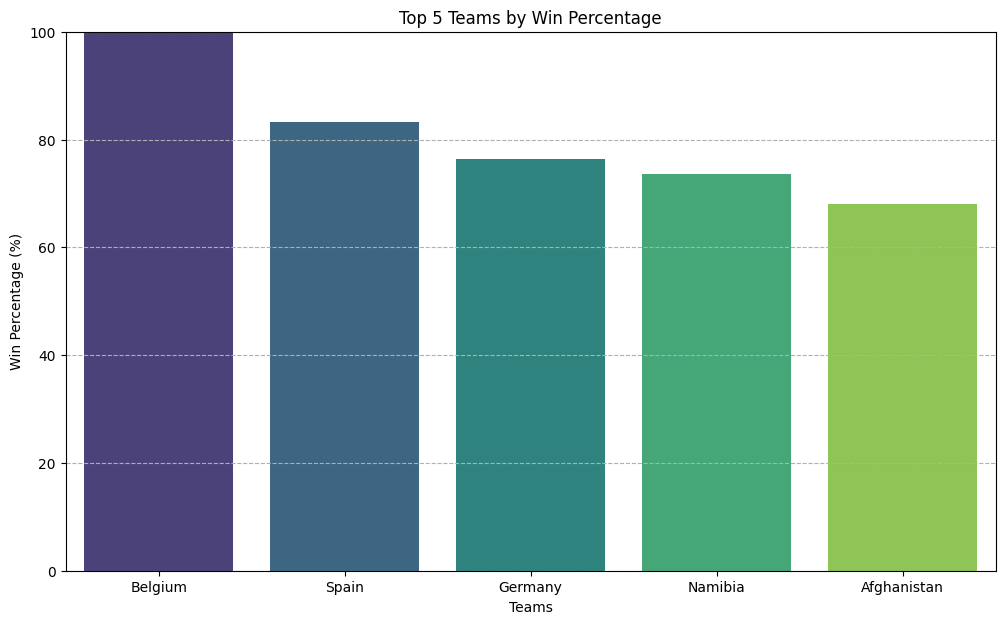

In [24]:
win_percentages = []

for team, stats in team_stats.items():
    matches_played = stats['matches_played']
    matches_won = stats['matches_won']
    if matches_played > 0:
        win_percentage = (matches_won / matches_played) * 100
        win_percentages.append({'team': team, 'win_percentage': win_percentage})


win_percentages_sorted = sorted(win_percentages, key=lambda x: x['win_percentage'], reverse=True)


top_5_teams = win_percentages_sorted[:5]

print("Top 5 Teams by Win Percentage:")
for team_data in top_5_teams:
    print(f"{team_data['team']}: {team_data['win_percentage']:.2f}%")


top_5_df = pd.DataFrame(top_5_teams)

plt.figure(figsize=(12, 7))
sns.barplot(x='team', y='win_percentage', data=top_5_df, hue='team', palette='viridis', legend=False)
plt.title('Top 5 Teams by Win Percentage')
plt.xlabel('Teams')
plt.ylabel('Win Percentage (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--')
plt.show()


In [25]:
def generate_scorecards(innings_data):
    batting_stats = {}
    bowling_stats = {}

    innings_details = []

    for inning in innings_data:
        inning_key = list(inning.keys())[0]
        inning_info = inning[inning_key]

        team = inning_info['team']
        deliveries = inning_info['deliveries']

        opponent_team = None
        if len(innings_data) > 1:
            if inning_key == '1st innings':
                opponent_team = innings_data[1]['2nd innings']['team']
            elif inning_key == '2nd innings':
                opponent_team = innings_data[0]['1st innings']['team']

        innings_details.append({
            'innings_key': inning_key,
            'batting_team': team,
            'bowling_team': opponent_team
        })

        for delivery in deliveries:
            delivery_info = list(delivery.values())[0]

            batsman = delivery_info['batsman']
            bowler = delivery_info['bowler']
            runs = delivery_info['runs']['batsman']

            if batsman not in batting_stats:
                batting_stats[batsman] = {'runs': 0}
            batting_stats[batsman]['runs'] += runs

            if bowler not in bowling_stats:
                bowling_stats[bowler] = {'wickets': 0}
            if 'wicket' in delivery_info:
                if 'fielders' not in delivery_info['wicket'] and delivery_info['wicket']['kind'] not in ['run out', 'retired hurt', 'obstructing the field']:
                    bowling_stats[bowler]['wickets'] += 1

    df_innings1_scorecard = pd.DataFrame()
    df_innings2_scorecard = pd.DataFrame()

    if innings_details:
        first_innings_batting_team = innings_details[0]['batting_team']
        first_innings_bowling_team = innings_details[1]['batting_team'] if len(innings_details) > 1 else None


        first_innings_delivery_batsmen = [d[list(d.keys())[0]]['batsman'] for d in innings_data[0]['1st innings']['deliveries'] if 'batsman' in d[list(d.keys())[0]]]
        top_batsmen_1st_innings = sorted([
            {'Player': player, 'Runs': stats['runs']}
            for player, stats in batting_stats.items() if player in first_innings_delivery_batsmen
        ], key=lambda x: x['Runs'], reverse=True)[:4]

        top_bowlers_1st_innings = []
        if first_innings_bowling_team:

            first_innings_delivery_bowlers = [d[list(d.keys())[0]]['bowler'] for d in innings_data[0]['1st innings']['deliveries'] if 'bowler' in d[list(d.keys())[0]]]
            top_bowlers_1st_innings = sorted([
                {'Player': player, 'Wickets': stats['wickets']}
                for player, stats in bowling_stats.items() if player in first_innings_delivery_bowlers
            ], key=lambda x: x['Wickets'], reverse=True)[:4]

        df_innings1_batting = pd.DataFrame(top_batsmen_1st_innings)
        df_innings1_bowling = pd.DataFrame(top_bowlers_1st_innings)

        df_innings1_scorecard = pd.concat([df_innings1_batting, df_innings1_bowling], axis=1)
        df_innings1_scorecard.columns = ['Batsman', 'Runs', 'Bowler', 'Wickets'] if not df_innings1_bowling.empty else ['Batsman', 'Runs']

        if len(innings_details) > 1:
            second_innings_batting_team = innings_details[1]['batting_team']
            second_innings_bowling_team = innings_details[0]['batting_team']


            second_innings_delivery_batsmen = [d[list(d.keys())[0]]['batsman'] for d in innings_data[1]['2nd innings']['deliveries'] if 'batsman' in d[list(d.keys())[0]]]
            top_batsmen_2nd_innings = sorted([
                {'Player': player, 'Runs': stats['runs']}
                for player, stats in batting_stats.items() if player in second_innings_delivery_batsmen
            ], key=lambda x: x['Runs'], reverse=True)[:4]


            second_innings_delivery_bowlers = [d[list(d.keys())[0]]['bowler'] for d in innings_data[1]['2nd innings']['deliveries'] if 'bowler' in d[list(d.keys())[0]]]
            top_bowlers_2nd_innings = sorted([
                {'Player': player, 'Wickets': stats['wickets']}
                for player, stats in bowling_stats.items() if player in second_innings_delivery_bowlers
            ], key=lambda x: x['Wickets'], reverse=True)[:4]

            df_innings2_batting = pd.DataFrame(top_batsmen_2nd_innings)
            df_innings2_bowling = pd.DataFrame(top_bowlers_2nd_innings)

            df_innings2_scorecard = pd.concat([df_innings2_batting, df_innings2_bowling], axis=1)
            df_innings2_scorecard.columns = ['Batsman', 'Runs', 'Bowler', 'Wickets'] if not df_innings2_bowling.empty else ['Batsman', 'Runs']

    return df_innings1_scorecard, df_innings2_scorecard

print("The `generate_scorecards` function has been defined.")

The `generate_scorecards` function has been defined.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/International_T20_Data.csv', engine='python', on_bad_lines='skip')
df.columns = df.columns.str.replace('.', '_', regex=False)

sample_innings_data = eval(df.loc[0, 'innings'])
df_innings1_scorecard, df_innings2_scorecard = generate_scorecards(sample_innings_data)
print("\nScorecard for 1st Innings:")
print(df_innings1_scorecard)
print("\nScorecard for 2nd Innings:")
print(df_innings2_scorecard)


Scorecard for 1st Innings:
     Batsman  Runs           Bowler  Wickets
0   AJ Finch    43       SL Malinga        0
1  M Klinger    38  KMDN Kulasekara        0
2    TM Head    31    JRMVB Sanjaya        0
3  AJ Turner    18       S Prasanna        0

Scorecard for 2nd Innings:
           Batsman  Runs       Bowler  Wickets
0    DAS Gunaratne    52    AJ Turner        1
1   EMDY Munaweera    44   PJ Cummins        0
2      N Dickwella    30   B Stanlake        0
3  TAM Siriwardana    15  JP Faulkner        0
